# House Price Prediction — EDA, Cleaning & Modeling

**Dataset:** Indian real-estate listings (`house_prices.csv`)

**Goal:** Clean a messy raw dataset column-by-column, engineer useful
features, then train/compare regression models to predict house price.

**Notebook structure**
1. Setup & Data Loading
2. Initial Inspection
3. Dropping Useless Columns
4. Column-by-Column Cleaning & Feature Engineering
5. Exploratory Visualization (raw, cleaned columns)
6. Train / Test Split (before any leakage-prone steps)
7. Target (`y`) Outlier Handling
8. Feature (`X`) Outlier Handling
9. Re-Visualization After Capping
10. Preprocessing Pipeline (`ColumnTransformer`)
11. Model Training & Evaluation
12. Save the Best Model
13. Summary & Key Takeaways


## 1. Setup & Data Loading

In [1]:
# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- Load the raw dataset ---
df = pd.read_csv("house_prices.csv")
df.head()


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


## 2. Initial Inspection

In [2]:
# Column dtypes, non-null counts, memory usage
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [3]:
# Quick statistical summary of numeric columns
df.describe()


,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [4]:
# Percentage of missing values per column -> tells us what needs
# imputing, engineering, or dropping outright
(df.isna().sum() / len(df)) * 100


Index                  0.000000
Title                  0.000000
Description            1.612000
Amount(in rupees)      0.000000
Price (in rupees)      9.419776
location               0.000000
Carpet Area           43.018488
Status                 0.327946
Floor                  3.773776
Transaction            0.044259
Furnishing             1.544811
facing                37.451408
overlooking           43.425354
Society               58.485264
Bathroom               0.441527
Balcony               26.094352
Car Parking           55.114621
Ownership             34.936624
Super Area            57.422506
Dimensions           100.000000
Plot Area            100.000000
dtype: float64

## 3. Dropping Useless Columns

- `Index`: just a row counter, carries no information.
- `Dimensions`, `Plot Area`: **100% missing**, so they add nothing.


In [5]:
df = df.drop(columns=["Index", "Dimensions", "Plot Area"])

# Standardize column names: lowercase, underscores instead of spaces
df.columns = df.columns.str.replace(" ", "_").str.lower()

df.head()


,title,description,amount(in_rupees),price_(in_rupees),location,carpet_area,status,floor,transaction,furnishing,facing,overlooking,society,bathroom,balcony,car_parking,ownership,super_area
0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN
3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN


## 4. Column-by-Column Cleaning & Feature Engineering

The dataset is messy (mixed units, free-text fields, inconsistent
formatting), so each column is inspected and cleaned individually.


### 4.1 `title`
No missing values. Contains a redundant BHK count (same info as `bathroom`), but also embeds a raw location string we can extract as a feature.

In [6]:
df['title'].unique()


<StringArray>
['1 BHK Ready to Occupy Flat for sale in Srushti Siddhi Mangal Murti Complex Bhiwandi',
                     '2 BHK Ready to Occupy Flat for sale in Dosti Vihar Pokhran Road',
            '2 BHK Ready to Occupy Flat for sale in Sunrise by Kalpataru Kolshet Road',
                                         '1 BHK Ready to Occupy Flat for sale Kasheli',
     '2 BHK Ready to Occupy Flat for sale in TenX Habitat Raymond Realty Pokhran Road',
                         '1 BHK Ready to Occupy Flat for sale in Virat Aangan Titwala',
                                          '1 BHK Ready to Occupy Flat for sale Mumbra',
                                           '1 BHK Ready to Occupy Flat for sale Kalwa',
                          '3 BHK Ready to Occupy Flat for sale in Pride Palms Kolshet',
             '3 BHK Ready to Occupy Flat for sale in Cosmos Lounge Manpada Thane West',
 ...
                  '3 BHK Ready to Occupy Flat for sale in Bollywood Heights 2 Dhakoli',
             

In [7]:
def extract_location_raw(title):
    """Pull the free-text location out of the listing title,
    e.g. '... Flat for sale in Thane' -> 'Thane'."""
    if pd.isna(title):
        return np.nan
    match = re.search(r'Flat for sale (?:in )?(.+)', title)
    if match:
        return match.group(1).strip()
    return np.nan

df['location_raw'] = df['title'].apply(extract_location_raw)


### 4.2 `description`
Largely duplicates the info in `title`, so we drop rows with no description, then drop the whole column.

In [8]:
df = df.dropna(subset=['description'])
df['description'].unique()


<StringArray>
[                                                                                                                                                                                                                     'Bhiwandi, Thane has an attractive 1 BHK Flat for sale. The property is ideally located in a strategic location in Srushti Siddhi Mangal Murti Complex township. This flat for resale is a choice property. This apartment ready to move in the Bhiwandi is available for an attractive price of INR 42 Lac. You will find it unfurnished.',
                                          'One can find this stunning 2 BHK flat for sale in Pokhran Road, Thane. It enjoys an excellent location within the Dosti Vihar. This flat for resale is a choice property. This ready to move flat in Pokhran Road can be availed at a reasonable price of INR 98 Lac. This semi-furnished flat is strategically designed with all the amenities to enhance the living experience. The property is strategica

In [9]:
df = df.drop(columns=["description"])


### 4.3 `amount(in_rupees)`
Values are strings like `'42 Lac'` or `'1.40 Cr'`. We parse the numeric part and the unit, then convert everything to a single rupee amount (`Lac` = 1e5, `Cr` = 1e7).

In [10]:
df['amount(in_rupees)'].unique()


<StringArray>
[    '42 Lac ',     '98 Lac ',    '1.40 Cr ',     '25 Lac ',    '1.60 Cr ',
     '45 Lac ',   '16.5 Lac ',     '60 Lac ',    '1.36 Cr ',    '1.35 Cr ',
 ...
   '11.3 Lac ',    '7.3 Lac ', '1400.30 Cr ',   '11.8 Lac ',    '7.8 Lac ',
    '8.8 Lac ',      '80 Cr ',    '1.5 Lac ',   '24.4 Lac ',    '9.90 Cr ']
Length: 1551, dtype: str

In [11]:
s = df['amount(in_rupees)'].str.strip().str.lower()

# Extract the unit ('lac' or 'cr') and the numeric value separately
unit = s.str.extract(r'(lac|cr)', expand=False)
number = s.str.extract(r'([\d.]+)', expand=False)
number = pd.to_numeric(number, errors='coerce')

def apply_unit(n, u):
    """Convert a (number, unit) pair into a plain rupee amount."""
    if u == 'lac':
        return n * 1e5
    elif u == 'cr':
        return n * 1e7
    else:
        return None

df['amount_in_rupees'] = [apply_unit(n, u) for n, u in zip(number, unit)]
df['amount_in_rupees'].unique()


array([ 4200000.,  9800000., 14000000., ...,   150000.,  2440000.,
       99000000.], shape=(1550,))

In [12]:
# Original string column no longer needed
df = df.drop(columns={"amount(in_rupees)"})

# How many listings still have no parsed amount?
df['amount_in_rupees'].isna().sum()


np.int64(9590)

### 4.4 `location`
City-level location, already clean categorical text.

In [13]:
df['location'].unique()
df['location'].value_counts()


location
new-delhi      27562
bangalore      23075
kolkata        21511
gurgaon        20001
ahmedabad      12699
               ...  
navsari           30
nellore           30
palakkad          30
pondicherry       30
solapur           30
Name: count, Length: 81, dtype: int64

### 4.5 `carpet_area`
Values like `'500 sqft'` or `'55 sqyrd'`. We convert everything to square feet (`1 sqyrd = 9 sqft`).

In [14]:
df['carpet_area'].unique()


<StringArray>
[ '500 sqft',  '473 sqft',  '779 sqft',  '530 sqft',  '635 sqft',         nan,
  '550 sqft',  '900 sqft',  '950 sqft', '1820 sqft',
 ...
 '2780 sqft', '1967 sqft', '3584 sqft',  '302 sqft', '2340 sqft', '1526 sqft',
 '128 sqyrd', '1634 sqft', '164 sqyrd',  '136 sqft']
Length: 2752, dtype: str

In [15]:
df['carpet_area'].isna().sum()


np.int64(77985)

In [16]:
def sqft_convert(s):
    """Parse a '<number> <unit>' area string and convert to sqft."""
    if pd.isna(s):
        return None

    s = s.strip()
    parts = s.split()
    if len(parts) != 2:
        return None

    num, unit = parts
    try:
        num = float(num)
    except ValueError:
        return None

    if unit == 'sqyrd':
        return num * 9
    elif unit == 'sqft':
        return num
    else:
        return None

df['carpet_area'] = df['carpet_area'].apply(sqft_convert)
df['carpet_area'].unique()
df['carpet_area'].isna().sum()


np.int64(78889)

### 4.6 `status`
Used only to drop rows with missing status, then dropped entirely (not predictive on its own for this analysis).

In [17]:
df = df.dropna(subset=['status'])
df = df.drop(columns={'status'})


### 4.7 `floor`
Values like `'10 out of 11'` or `'Ground'`. We split this into two numeric features (`floor_number`, `building_height`) plus a derived ratio.

In [18]:
df['floor'].unique()


<StringArray>
[            '10 out of 11',              '3 out of 22',
             '10 out of 29',               '1 out of 3',
             '20 out of 42',               '2 out of 7',
               '4 out of 5',          'Ground out of 7',
          'Ground out of 2',              '3 out of 27',
 ...
 'Upper Basement out of 24',           '200 out of 200',
             '33 out of 43',             '35 out of 37',
              '7 out of 41', 'Lower Basement out of 15',
              '2 out of 36',           'Lower Basement',
              '5 out of 50',              '7 out of 70']
Length: 942, dtype: str

In [19]:
floor_label = df['floor'].str.extract(r'^(.*?)(?:\s+out of\s+(\d+))?$')

def map_floor(label):
    """Map a floor label to a numeric floor index.
    Ground -> 0, Upper Basement -> -1, Lower Basement -> -2,
    otherwise parse the number directly."""
    if pd.isna(label):
        return None
    label = label.strip().lower()
    if label == 'ground':
        return 0
    elif label == 'upper basement':
        return -1
    elif label == 'lower basement':
        return -2
    else:
        try:
            return float(label)
        except ValueError:
            return None

df['floor_number'] = floor_label[0].apply(map_floor)
df['building_height'] = pd.to_numeric(floor_label[1], errors='coerce')

# Relative position of the unit within the building (0 = ground, 1 = top)
df['floor_ratio'] = df['floor_number'] / df['building_height']


In [20]:
df = df.drop(columns={"floor"})


### 4.8 `transaction`
Drop the small number of rows with no value; the column itself is a clean low-cardinality categorical.

In [21]:
df = df.dropna(subset=['transaction'])
df['transaction'].value_counts()


transaction
Resale          142050
New Property     41074
Other              709
Name: count, dtype: int64

### 4.9 `furnishing`

In [22]:
df['furnishing'].unique()


<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished', nan]
Length: 4, dtype: str

### 4.10 `facing`
~37% missing — kept as a categorical feature with imputation handled later in the preprocessing pipeline.

In [23]:
df['facing'].unique()
df['facing'].isna().sum()  # ~37.45% missing


np.int64(67250)

### 4.11 `overlooking`
Multi-value field (comma-separated). We strip the placeholder `'Not Available'` entries and normalize ordering so that equivalent combinations map to the same string.

In [24]:
df['overlooking'].unique()


<StringArray>
[                                          nan,
                                 'Garden/Park',
                      'Garden/Park, Main Road',
                                   'Main Road',
                'Pool, Garden/Park, Main Road',
                'Garden/Park, Pool, Main Road',
                           'Garden/Park, Pool',
                      'Main Road, Garden/Park',
                'Main Road, Garden/Park, Pool',
                           'Pool, Garden/Park',
                                        'Pool',
                'Garden/Park, Main Road, Pool',
                             'Pool, Main Road',
                'Main Road, Pool, Garden/Park',
                'Pool, Main Road, Garden/Park',
                    'Main Road, Not Available',
                             'Main Road, Pool',
 'Garden/Park, Pool, Main Road, Not Available',
                  'Garden/Park, Not Available',
              'Pool, Main Road, Not Available']
Length: 20, dtype: str

In [25]:
def clean_overlooking(val):
    """Remove 'Not Available' entries and sort remaining values so
    combinations like 'A, B' and 'B, A' are treated as identical."""
    if pd.isna(val):
        return val
    parts = [p.strip() for p in val.split(',')]
    parts = [p for p in parts if p != 'Not Available']
    if not parts:
        return np.nan
    return ', '.join(sorted(parts))

df['overlooking'] = df['overlooking'].apply(clean_overlooking)
df['overlooking'].unique()


<StringArray>
[                           nan,                  'Garden/Park',
       'Garden/Park, Main Road',                    'Main Road',
 'Garden/Park, Main Road, Pool',            'Garden/Park, Pool',
                         'Pool',              'Main Road, Pool']
Length: 8, dtype: str

### 4.12 `society` -> `locality`
We derive a cleaner `locality` feature: if `location_raw` starts with the society name, strip it off; otherwise `location_raw` itself is the locality.

In [26]:
df['society'].value_counts()


society
Hamdam Apartment              1648
Malibu Town                   1158
Shree Vardhman Victoria       1154
DLF Skycourt                  1153
Nebula Tower                   982
                              ... 
Sushma Capital                   1
Sushma Chandigarh Infinium       1
Silver City Greens               1
Nirmaan Royale Empire            1
Jaivee Radha Enclave             1
Name: count, Length: 10132, dtype: int64

In [27]:
def get_locality(row):
    """Derive the neighborhood/locality from the raw title location,
    removing the society name prefix if present."""
    raw = row['location_raw']
    soc = row['society']
    if pd.isna(raw):
        return np.nan
    if pd.notna(soc) and raw.lower().startswith(soc.lower()):
        return raw[len(soc):].strip()
    return raw  # no society -> raw text IS the locality

df['locality'] = df.apply(get_locality, axis=1)


### 4.13 `bathroom`
Values like `'> 5'` are cleaned to plain numbers.

In [28]:
df['bathroom'].unique()
df['bathroom'] = df['bathroom'].str.replace("> ", "")
df['bathroom'] = pd.to_numeric(df['bathroom'])


In [29]:
df = df.dropna(subset=['bathroom'])
df['bathroom'].unique()


array([ 1.,  2.,  3.,  4.,  6.,  5., 10.,  9.,  8.,  7.])

### 4.14 `balcony`

In [30]:
df['balcony'] = df['balcony'].str.replace("> ", "")
df['balcony'] = pd.to_numeric(df['balcony'])
df['balcony'].unique()


array([ 2., nan,  1.,  3.,  4., 10.,  6.,  5.,  7.,  8.,  9.])

### 4.15 `car_parking`
Values like `'1 Open'` / `'2 Covered'` are split into a numeric `parking_count` and a categorical `parking_type`. Counts above 10 are treated as data-entry errors and set to missing.

In [31]:
df['car_parking'].unique()


<StringArray>
[          nan,      '1 Open',   '1 Covered',   '2 Covered',  '66 Covered',
 '701 Covered',   '3 Covered',  '1 Covered,',     '35 Open', '323 Covered',
 ...
 '304 Covered', '207 Covered', '206 Covered', '104 Covered', '416 Covered',
 '205 Covered',    '300 Open', '11 Covered,', '403 Covered',    '702 Open']
Length: 229, dtype: str

In [32]:
# Extract numeric count and type (Open / Covered) into separate columns
extracted = df['car_parking'].str.strip(',').str.extract(r'(\d+)\s*(Open|Covered)')
df['parking_count'] = pd.to_numeric(extracted[0])
df['parking_type'] = extracted[1]

# Sanity check the distribution of parking_count
df['parking_count'].describe()
df['parking_count'].value_counts().sort_index(ascending=False).head(20)


parking_count
999.0    2
908.0    1
903.0    1
901.0    1
835.0    1
808.0    1
804.0    1
801.0    2
706.0    1
704.0    1
703.0    2
702.0    2
701.0    4
653.0    1
621.0    1
605.0    2
604.0    2
601.0    4
571.0    1
536.0    1
Name: count, dtype: int64

In [33]:
# Treat implausibly large counts (>10) as bad data -> missing
df.loc[df['parking_count'] > 10, 'parking_count'] = np.nan
df['parking_count'].value_counts().sort_index()


parking_count
1.0     62477
2.0     17238
3.0       579
4.0       164
5.0        71
6.0        36
7.0        17
8.0       214
9.0        11
10.0      866
Name: count, dtype: int64

### 4.16 `ownership`

In [34]:
df['ownership'].unique()


<StringArray>
[nan, 'Freehold', 'Co-operative Society', 'Power Of Attorney', 'Leasehold']
Length: 5, dtype: str

### 4.17 `super_area`
Same unit-conversion logic as `carpet_area`.

In [35]:
df['super_area'].unique()


<StringArray>
[          nan,    '680 sqft',    '575 sqft',    '600 sqft',   '1165 sqft',
    '844 sqft',    '650 sqft',    '540 sqft',    '520 sqft',    '525 sqft',
 ...
 '13,000 sqft',   '2004 sqft',    '429 sqft',   '147 sqyrd',   '217 sqyrd',
   '2066 sqft',    '406 sqft',   '2332 sqft',   '2555 sqft',    '709 sqft']
Length: 2899, dtype: str

In [36]:
def parse_area(val):
    """Parse a '<number> <unit>' super-area string and convert to sqft."""
    if pd.isna(val):
        return np.nan
    val = val.replace(',', '').strip()
    match = re.match(r'([\d.]+)\s*(sqft|sqyrd)', val)
    if match:
        num, unit = match.groups()
        num = float(num)
        return num * 9 if unit == 'sqyrd' else num
    return np.nan

df['super_area'] = df['super_area'].apply(parse_area)
df.head()


,title,price_(in_rupees),location,carpet_area,transaction,furnishing,facing,overlooking,society,bathroom,...,ownership,super_area,location_raw,amount_in_rupees,floor_number,building_height,floor_ratio,locality,parking_count,parking_type
0,1 BHK Ready to Occupy Flat for sale in Srushti...,6000.0,thane,500.0,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex Bhiwandi,4200000.0,10.0,11.0,0.909091,Bhiwandi,NaN,NaN
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,13799.0,thane,473.0,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,...,Freehold,NaN,Dosti Vihar Pokhran Road,9800000.0,3.0,22.0,0.136364,Pokhran Road,1.0,Open
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,17500.0,thane,779.0,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,...,Freehold,NaN,Sunrise by Kalpataru Kolshet Road,14000000.0,10.0,29.0,0.344828,Kolshet Road,1.0,Covered
3,1 BHK Ready to Occupy Flat for sale Kasheli,NaN,thane,530.0,Resale,Unfurnished,NaN,NaN,NaN,1.0,...,NaN,NaN,Kasheli,2500000.0,1.0,3.0,0.333333,Kasheli,NaN,NaN
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,18824.0,thane,635.0,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,...,Co-operative Society,NaN,TenX Habitat Raymond Realty Pokhran Road,16000000.0,20.0,42.0,0.476190,Pokhran Road,1.0,Covered


## 5. Exploratory Visualization

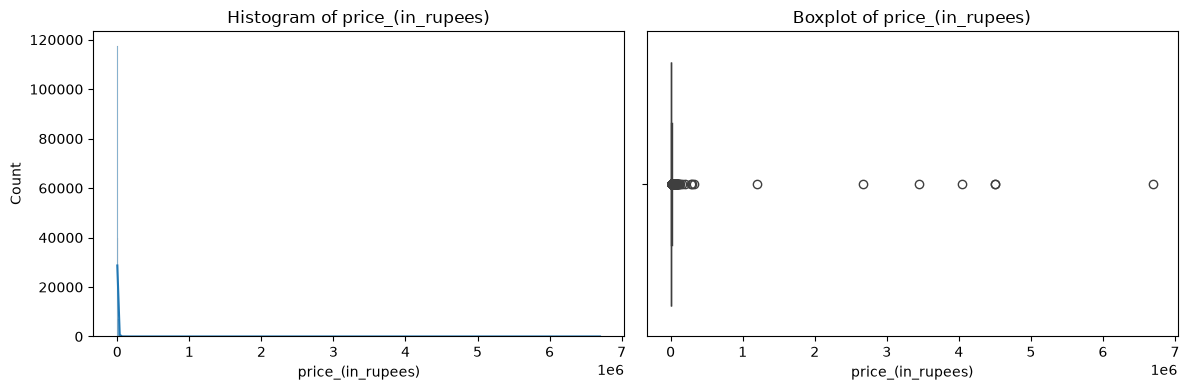

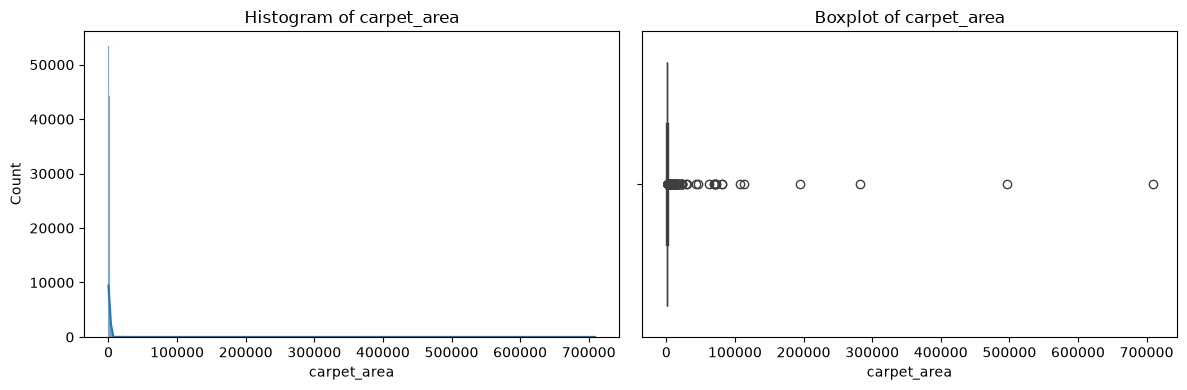

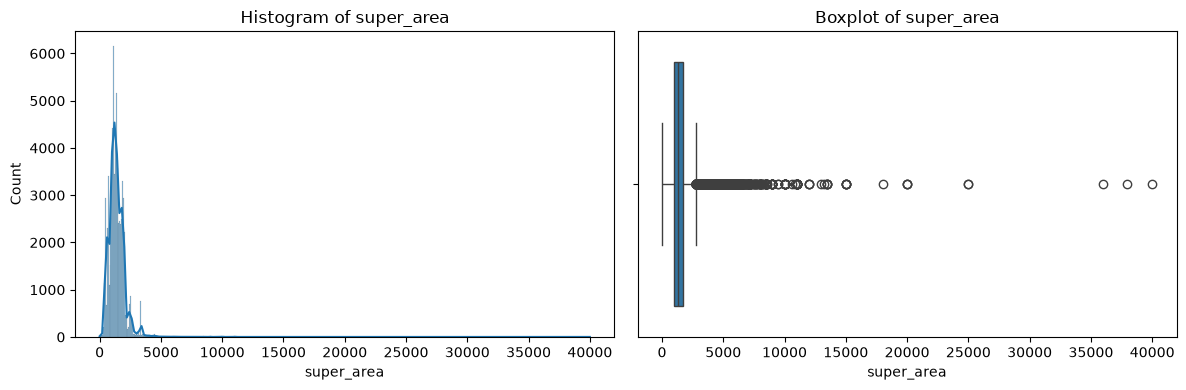

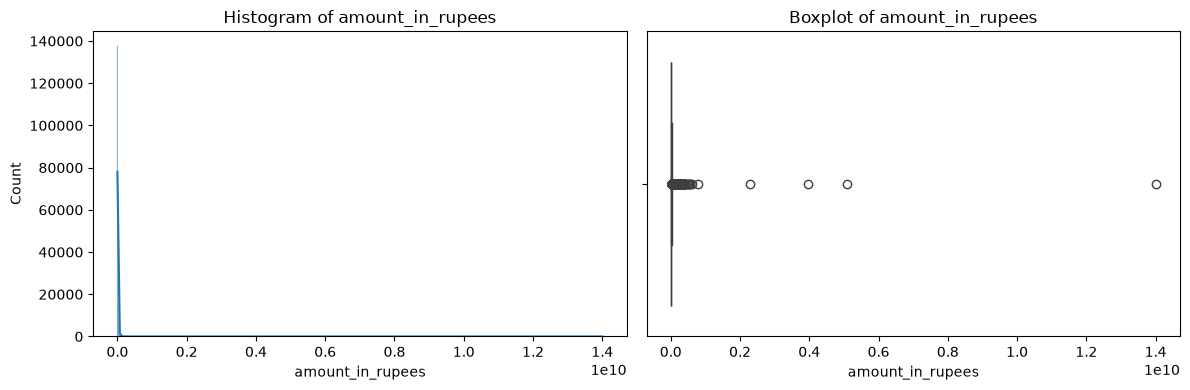

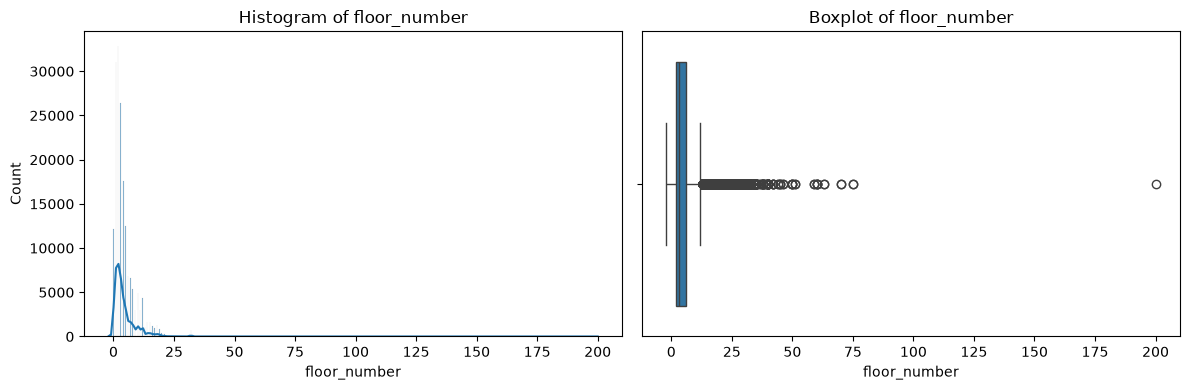

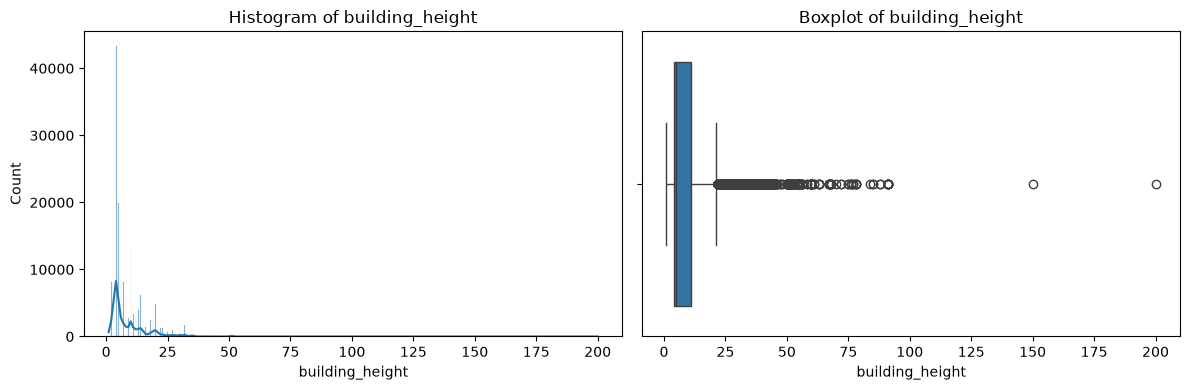

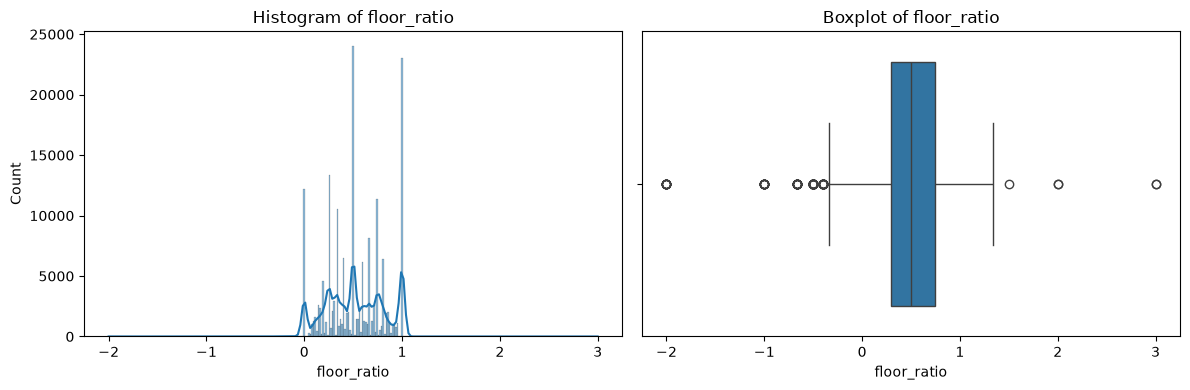

In [37]:
# ---- Numeric columns: distribution + outlier shape ----
numeric_cols = [
    'price_(in_rupees)', 'carpet_area', 'super_area', 'amount_in_rupees',
    'floor_number', 'building_height', 'floor_ratio'
]

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()


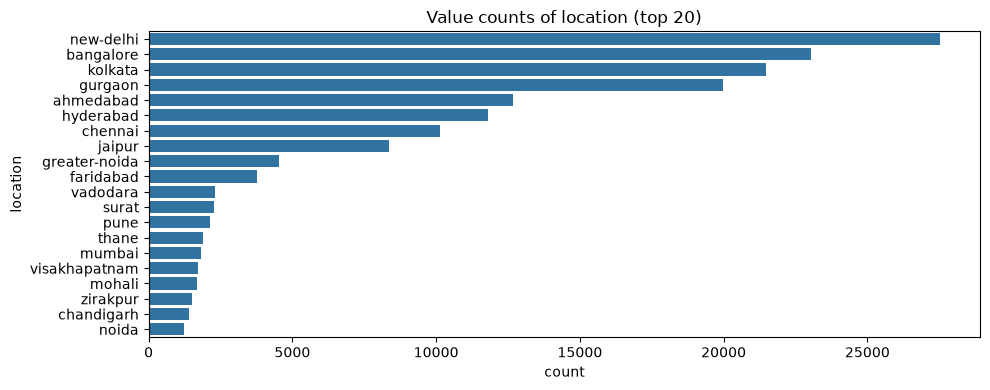

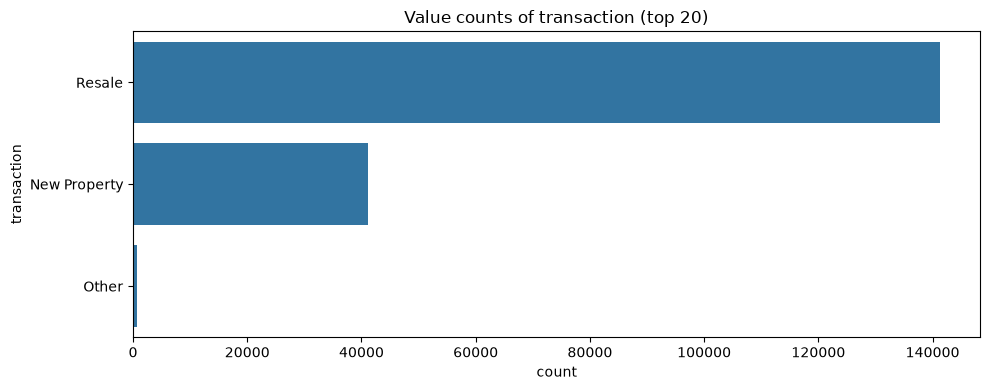

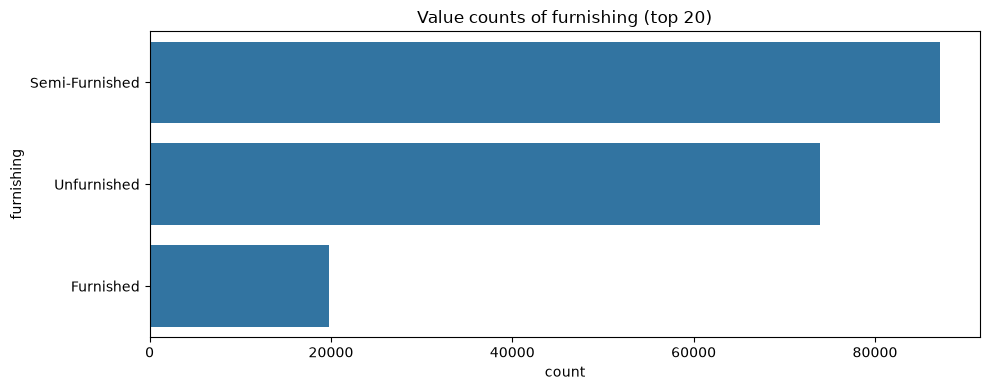

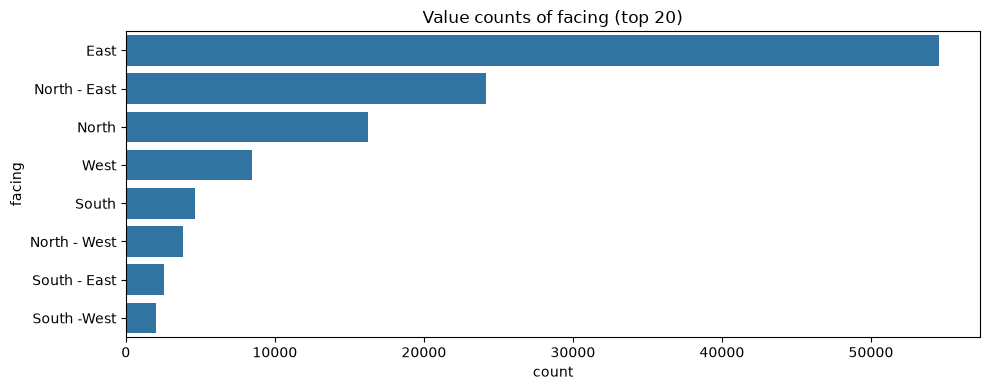

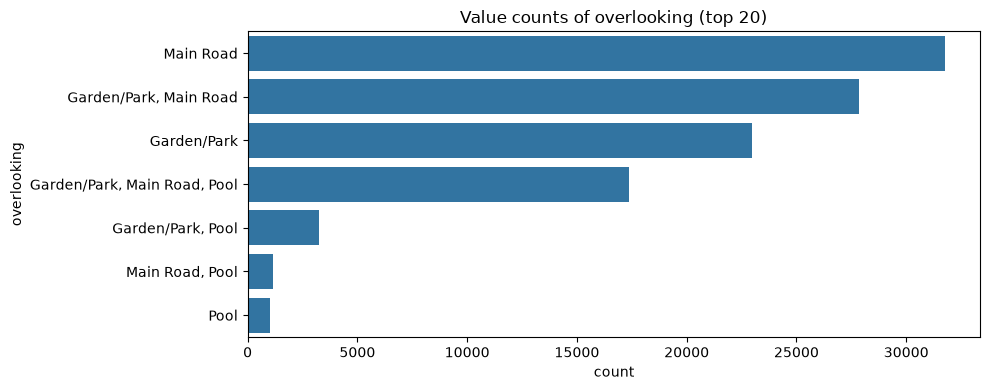

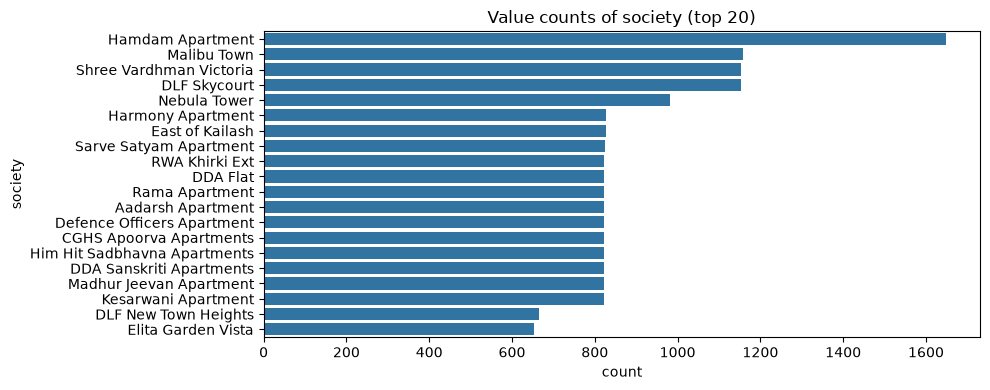

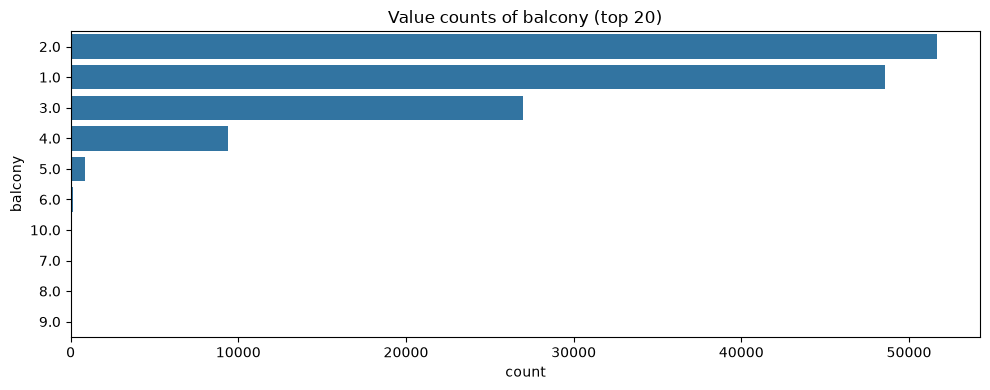

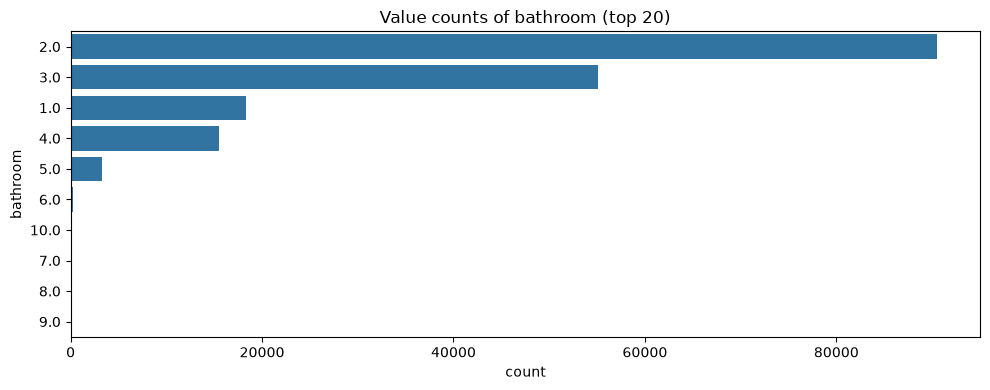

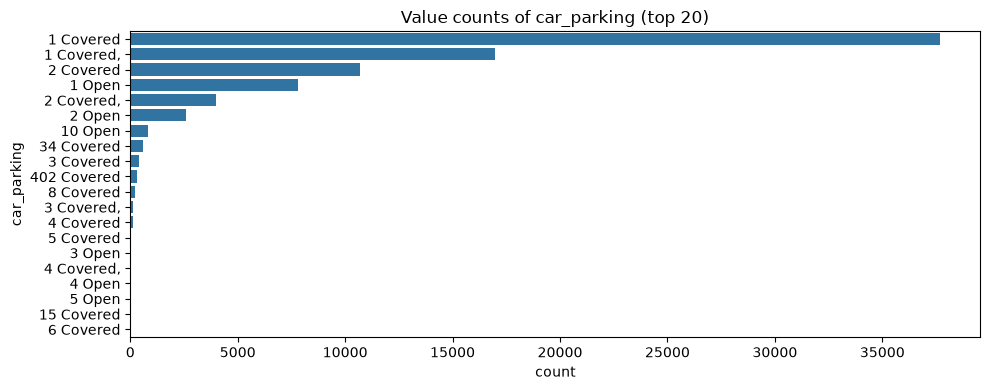

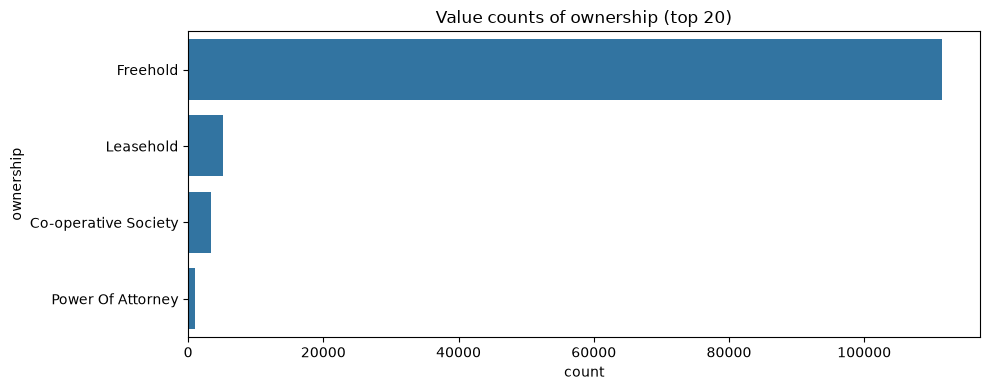

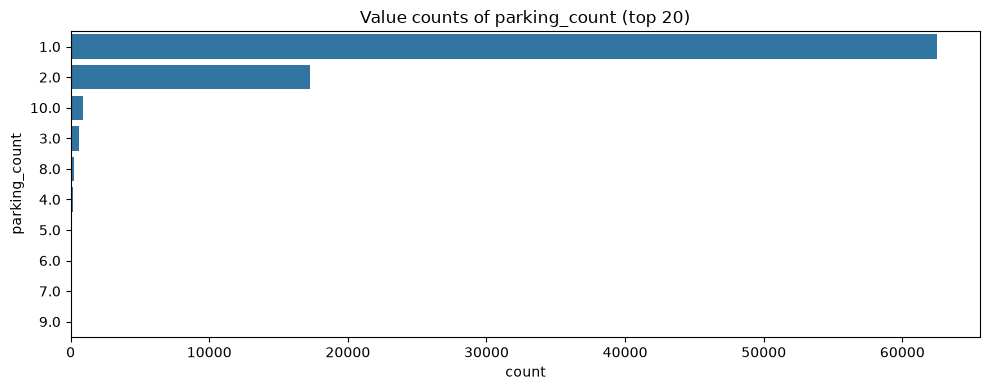

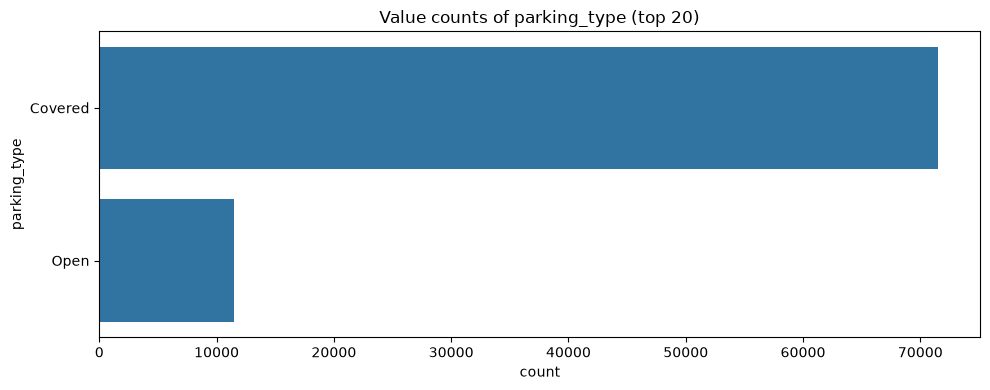

In [38]:
# ---- Categorical columns: frequency of top categories ----
categorical_cols = [
    'location', 'transaction', 'furnishing', 'facing',
    'overlooking', 'society', 'balcony', 'bathroom', 'car_parking',
    'ownership', 'parking_count', 'parking_type'
]

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().iloc[:20].index  # top 20 for readability
    sns.countplot(y=df[col], order=order)
    plt.title(f'Value counts of {col} (top 20)')
    plt.tight_layout()
    plt.show()


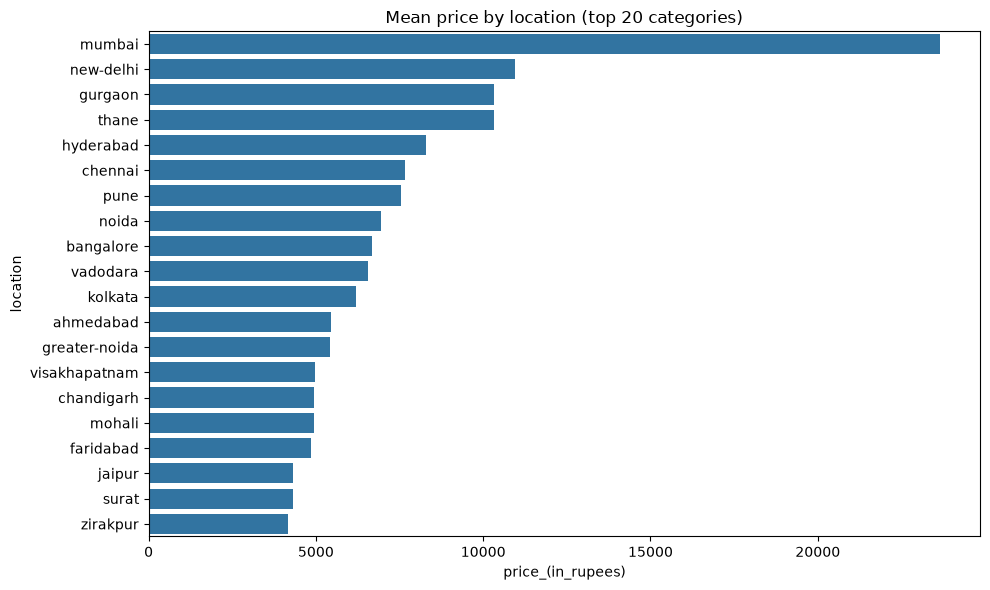

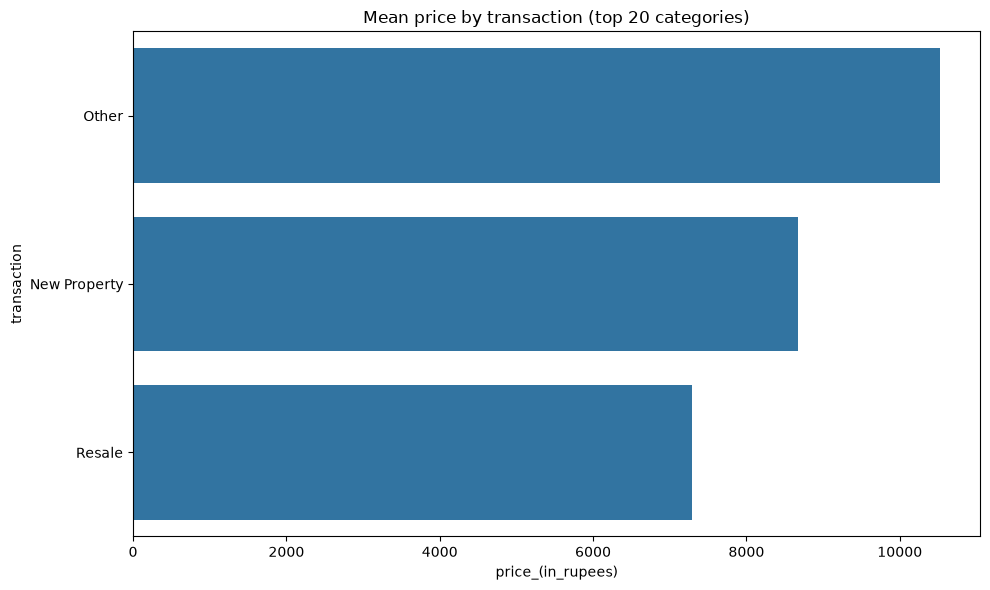

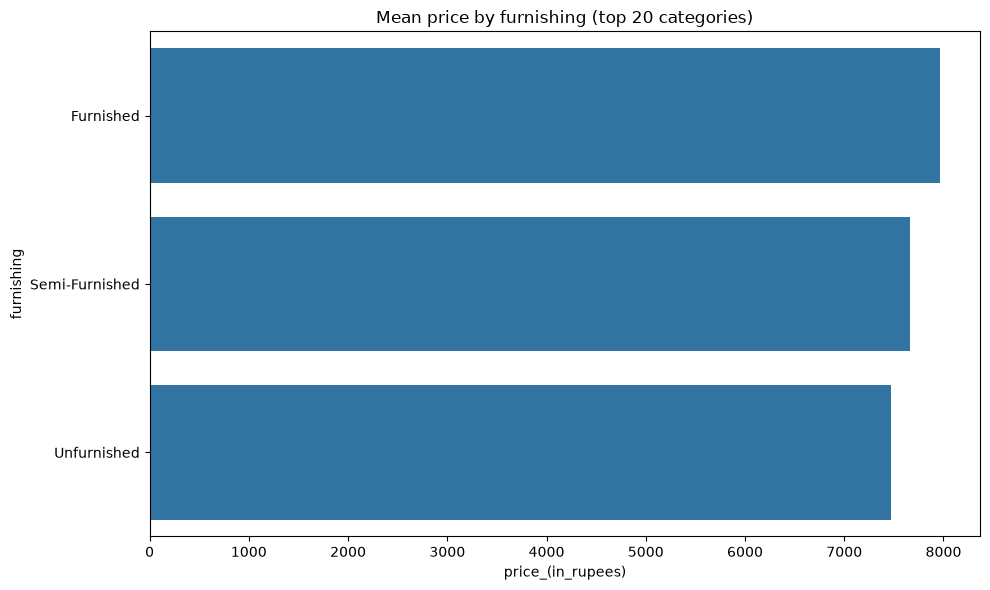

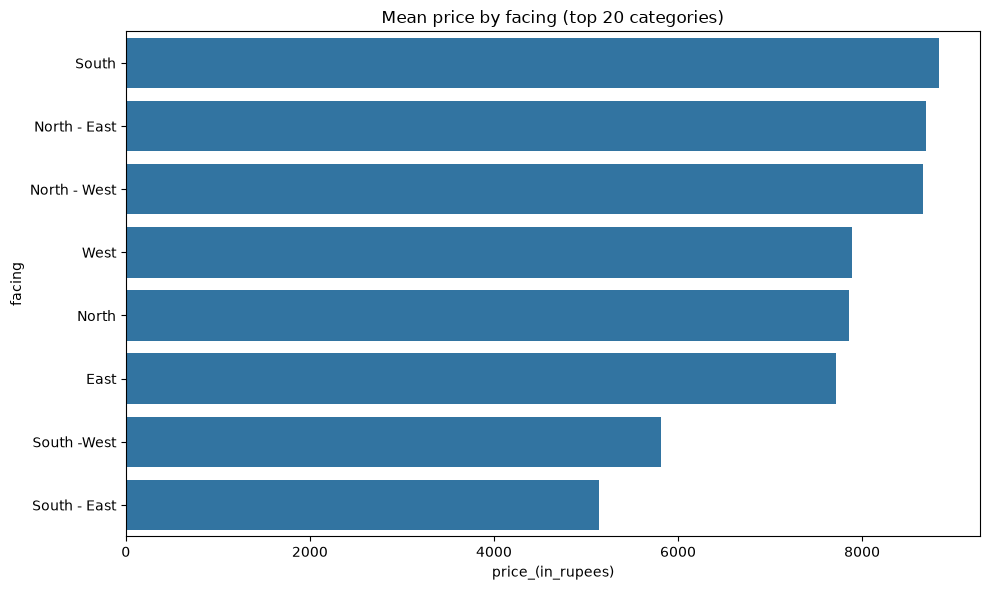

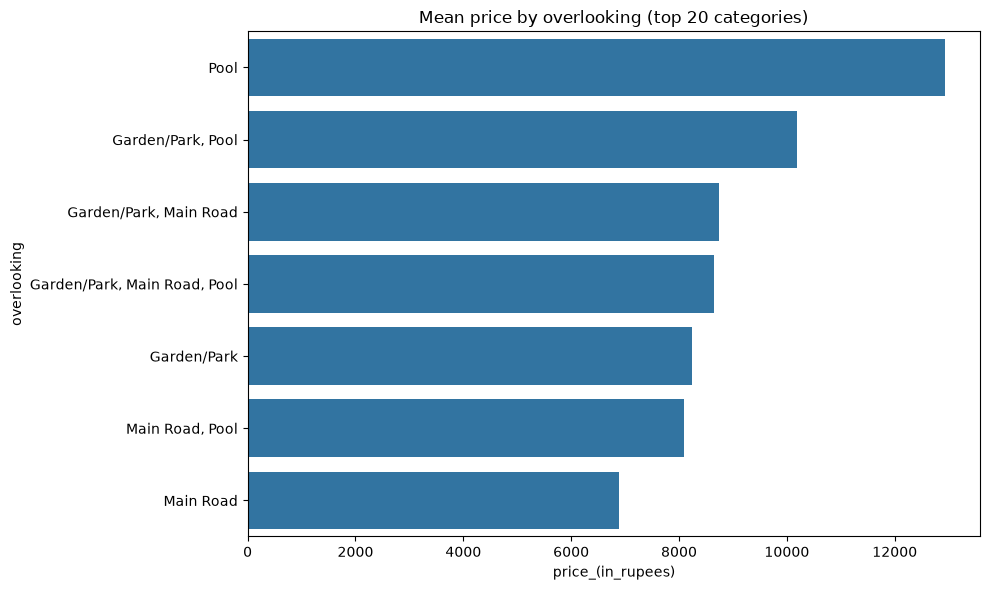

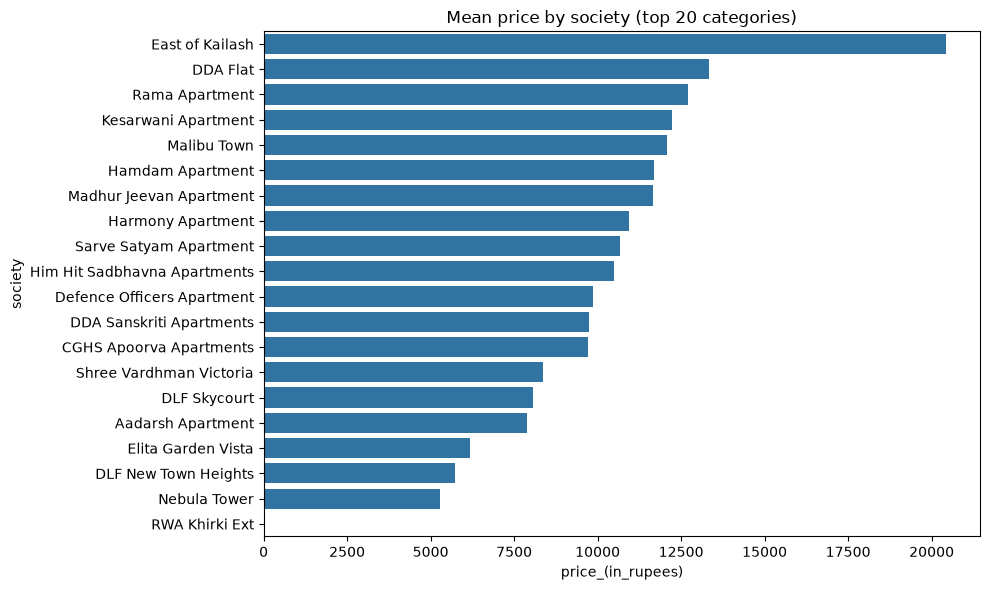

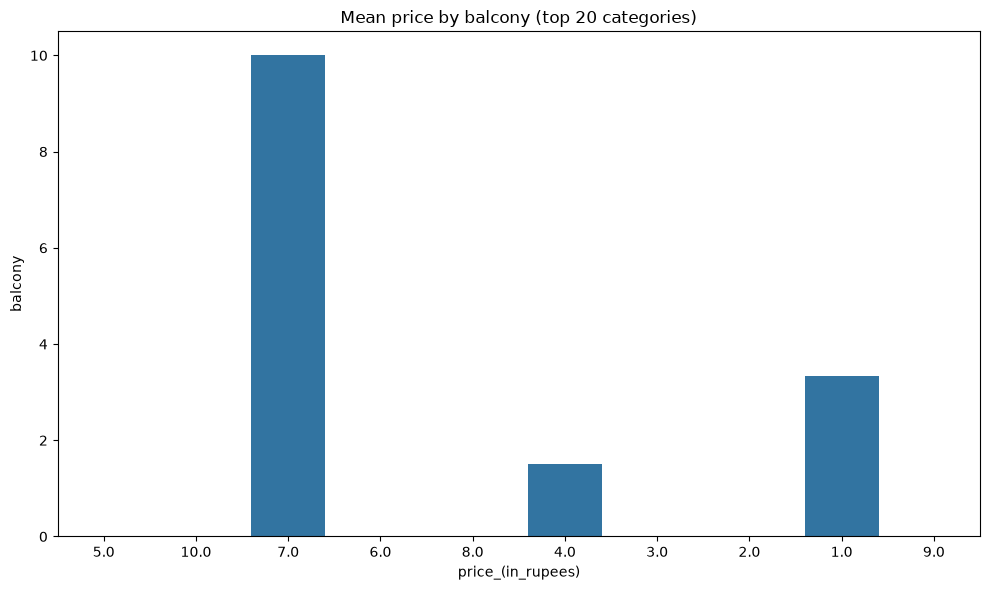

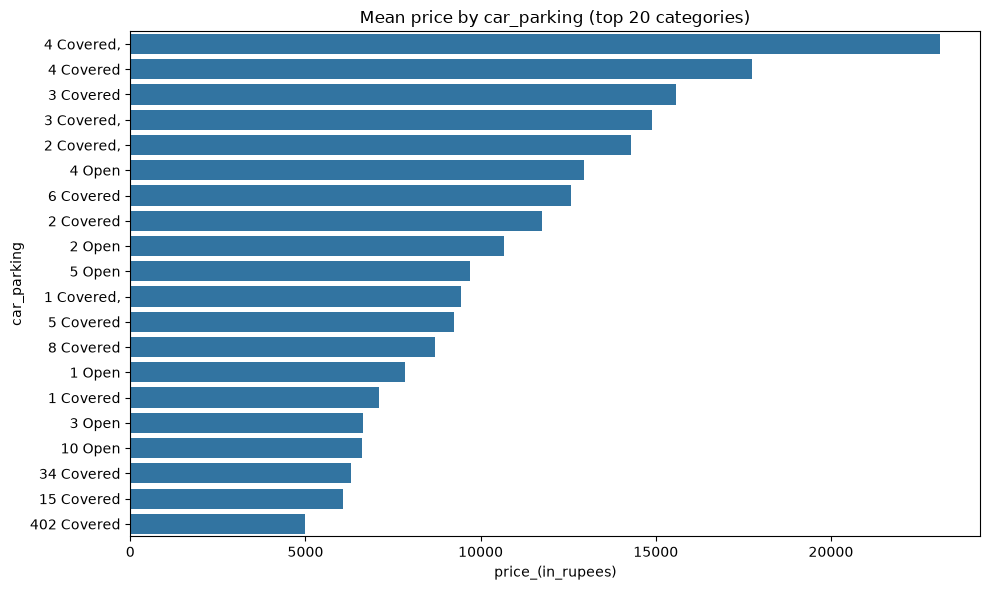

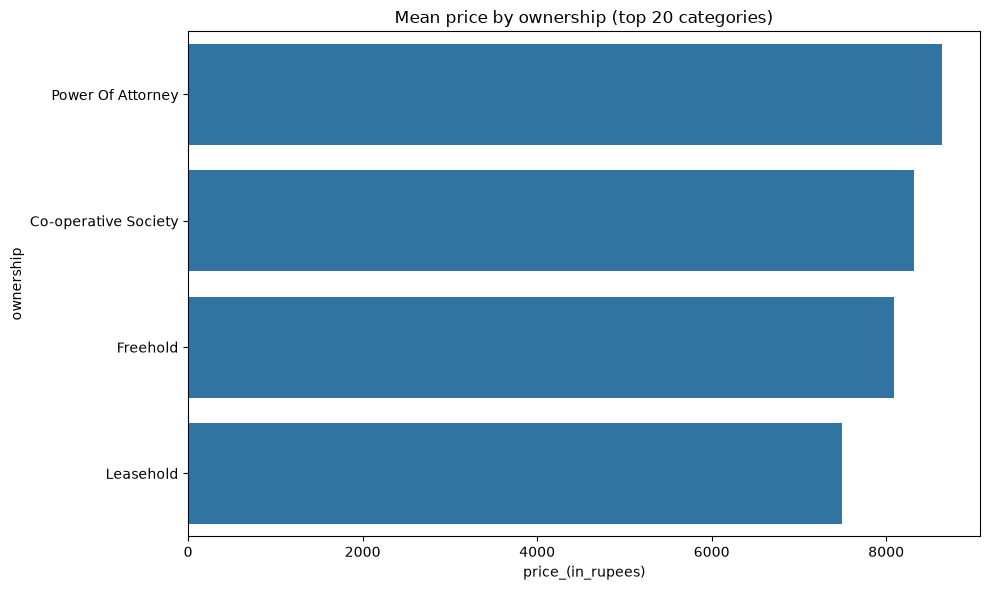

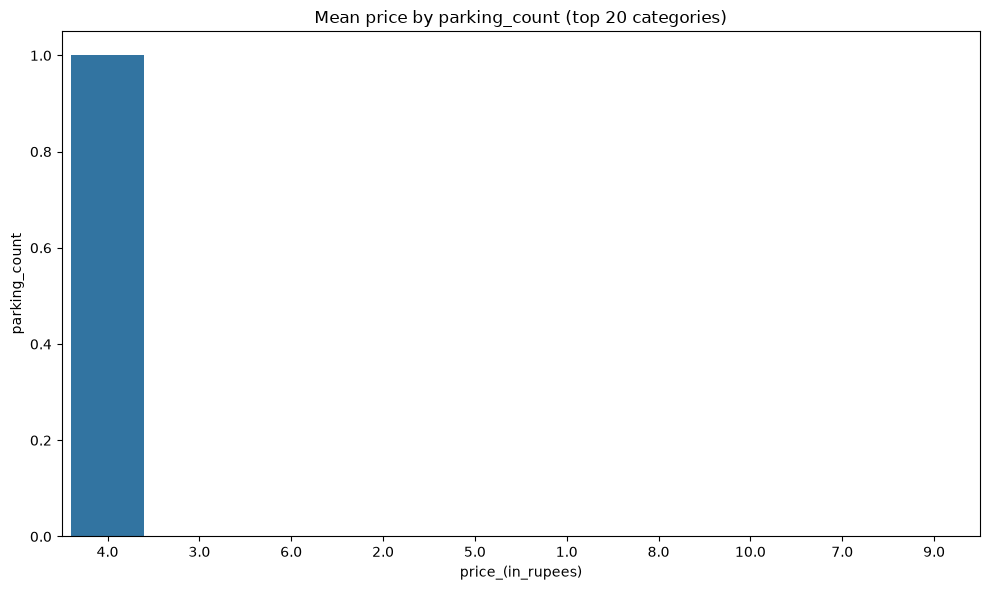

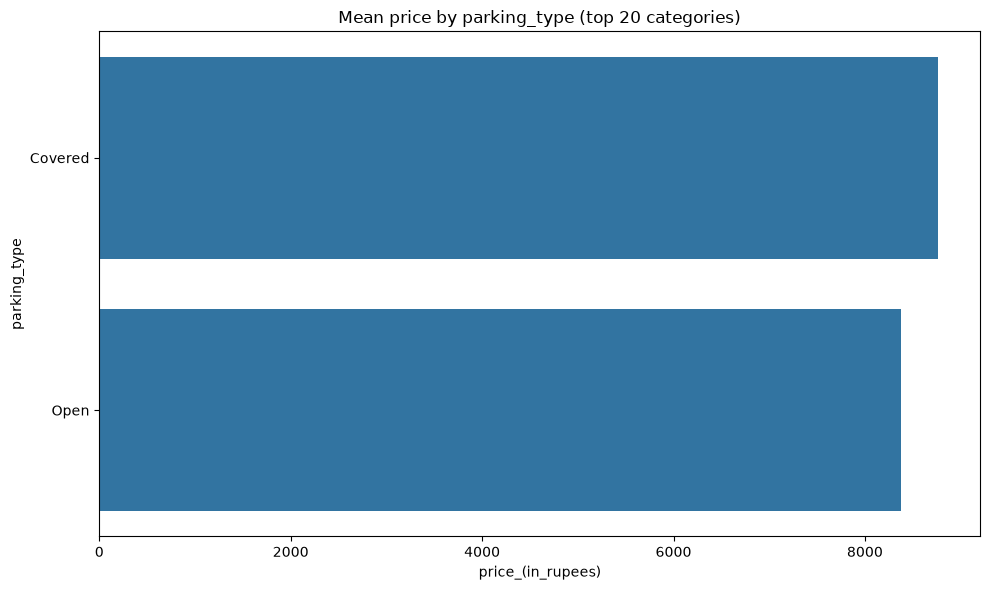

In [39]:
# ---- Categorical columns vs. mean price ----
categorical_cols = [
    'location', 'transaction', 'furnishing', 'facing',
    'overlooking', 'society', 'balcony', 'car_parking', 'ownership',
    'parking_count', 'parking_type'
]

for col in categorical_cols:
    top_categories = df[col].value_counts().iloc[:20].index
    subset = df[df[col].isin(top_categories)]

    plt.figure(figsize=(10, 6))
    order = subset.groupby(col)['price_(in_rupees)'].mean().sort_values(ascending=False).index
    sns.barplot(data=subset, y=col, x='price_(in_rupees)', order=order, errorbar=None)
    plt.title(f'Mean price by {col} (top 20 categories)')
    plt.tight_layout()
    plt.show()


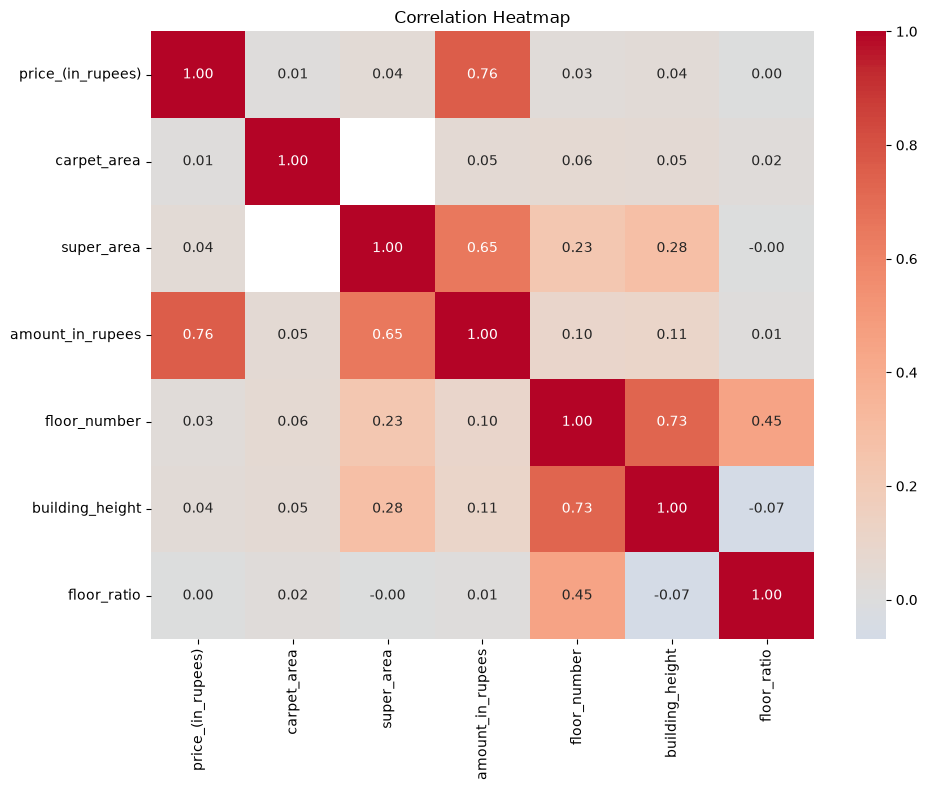

In [40]:
# ---- Correlation heatmap of numeric features ----
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [41]:
# Re-check dtypes and missingness after all the cleaning above
df.info()
(df.isna().sum() / len(df)) * 100


<class 'pandas.DataFrame'>
Index: 183020 entries, 0 to 187530
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   title              183020 non-null  str    
 1   price_(in_rupees)  165660 non-null  float64
 2   location           183020 non-null  str    
 3   carpet_area        105433 non-null  float64
 4   transaction        183020 non-null  str    
 5   furnishing         181012 non-null  str    
 6   facing             116547 non-null  str    
 7   overlooking        105390 non-null  str    
 8   society            76466 non-null   str    
 9   bathroom           183020 non-null  float64
 10  balcony            137659 non-null  float64
 11  car_parking        82979 non-null   str    
 12  ownership          121209 non-null  str    
 13  super_area         75028 non-null   float64
 14  location_raw       182167 non-null  str    
 15  amount_in_rupees   173531 non-null  float64
 16  floor_number      

title                 0.000000
price_(in_rupees)     9.485302
location              0.000000
carpet_area          42.392635
transaction           0.000000
furnishing            1.097148
facing               36.320074
overlooking          42.416129
society              58.219867
bathroom              0.000000
balcony              24.784723
car_parking          54.661239
ownership            33.772812
super_area           59.005573
location_raw          0.466069
amount_in_rupees      5.184679
floor_number          2.844498
building_height       2.866353
floor_ratio           2.866353
locality              0.466069
parking_count        55.374822
parking_type         54.661239
dtype: float64

## 6. Train / Test Split (Split FIRST to Prevent Data Leakage)

We split into train/test **before** any outlier handling, scaling, or
imputation. All statistics (IQR bounds, medians, scalers) must be learned
**strictly from the training set** (`X_train`, `y_train`) and then applied
to `X_test`, `y_test` — never the other way around.


In [42]:
from sklearn.model_selection import train_test_split

# 1. Drop rows missing the target variable
df_clean = df.dropna(subset=['price_(in_rupees)']).copy()

# 2. Drop redundant/raw columns that shouldn't be fed to the model
#    (raw parking fields already re-encoded, free-text title, the amount
#    column which duplicates price info, and the raw society name which
#    is now captured by 'locality')
df_clean = df_clean.drop(
    columns=['car_parking', 'parking_type', 'title', 'amount_in_rupees', 'society'],
    errors='ignore'
)

# 3. Separate features (X) and target (y)
X = df_clean.drop(columns=['price_(in_rupees)'])
y = df_clean['price_(in_rupees)']

# 4. Split 80% train / 20% test (fixed random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")
print(f"Target missing count: {y_train.isna().sum()} (Train), {y_test.isna().sum()} (Test)")


X_train shape: (132528, 16), X_test shape: (33132, 16)
y_train shape: (132528,), y_test shape: (33132,)
Target missing count: 0 (Train), 0 (Test)


In [43]:
import joblib

# Hand the split off to the modeling script (02_modeling.py)
joblib.dump((X_train, X_test, y_train, y_test), "train_test_split.joblib")


['train_test_split.joblib']